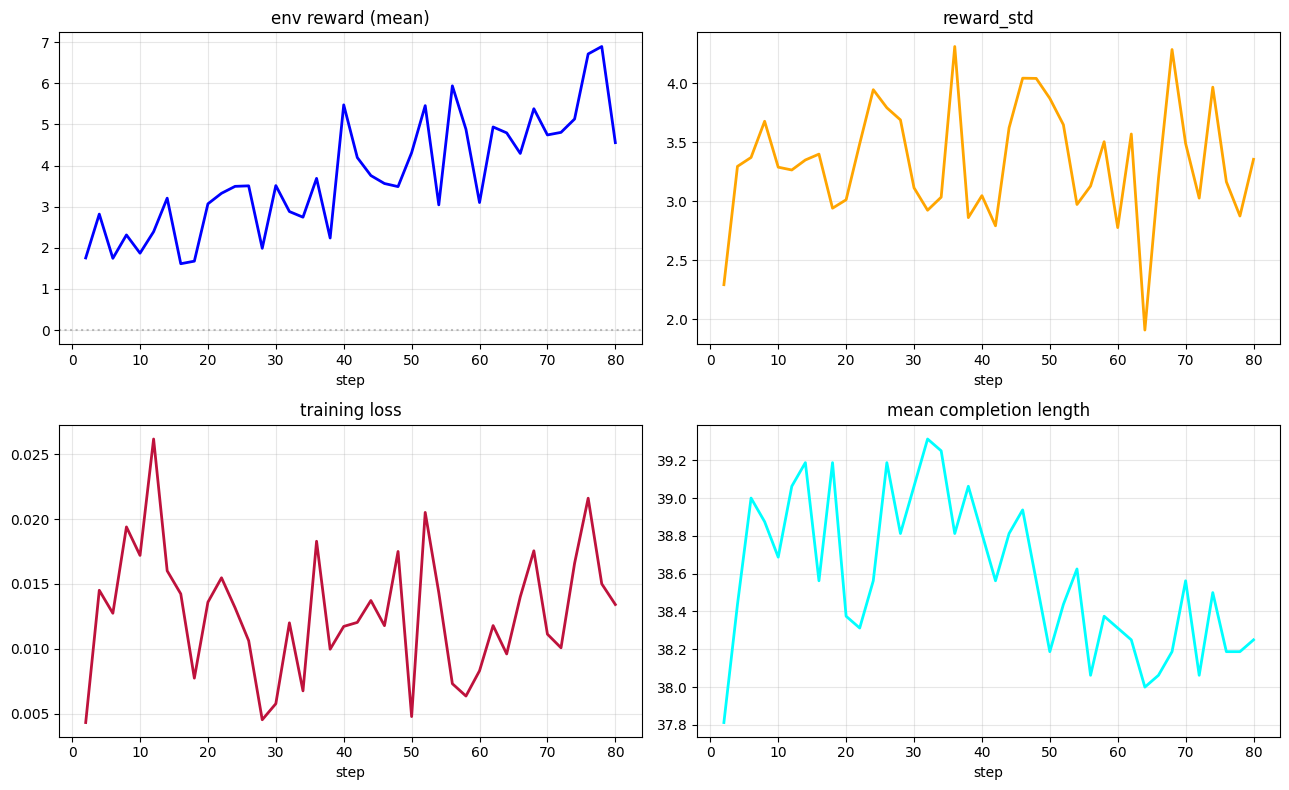

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / compute_rewards / mean,rewards / compute_rewards / std
2,0.004308,1.753125,2.293759,37.812500,36.500000,40.500000,0.000000,37.812500,36.500000,40.500000,0.847589,1.753125,2.293759
4,0.014513,2.818750,3.296996,38.437500,36.500000,40.500000,0.000000,38.437500,36.500000,40.500000,0.728569,2.818750,3.296996
6,0.012740,1.743750,3.372555,39.000000,37.500000,40.500000,0.000000,39.000000,37.500000,40.500000,0.777343,1.743750,3.372555
8,0.019402,2.312500,3.679376,38.875000,36.500000,40.500000,0.000000,38.875000,36.500000,40.500000,0.778288,2.312500,3.679376
10,0.017205,1.868750,3.290249,38.687500,37.000000,40.500000,0.000000,38.687500,37.000000,40.500000,0.733403,1.868750,3.290249
12,0.026185,2.390625,3.266477,39.062500,37.000000,41.000000,0.000000,39.062500,37.000000,41.000000,0.877311,2.390625,3.266477
14,0.016017,3.206250,3.351263,39.187500,37.000000,41.000000,0.000000,39.187500,37.000000,41.000000,0.675421,3.206250,3.351263
16,0.014237,1.612500,3.400915,38.562500,36.000000,42.000000,0.000000,38.562500,36.000000,42.000000,0.663877,1.612500,3.400915
18,0.007734,1.675000,2.942400,39.187500,37.500000,41.000000,0.000000,39.187500,37.500000,41.000000,0.573325,1.675000,2.942401
20,0.013598,3.068750,3.013997,38.375000,37.000000,39.000000,0.000000,38.375000,37.000000,39.000000,0.609985,3.068750,3.013996


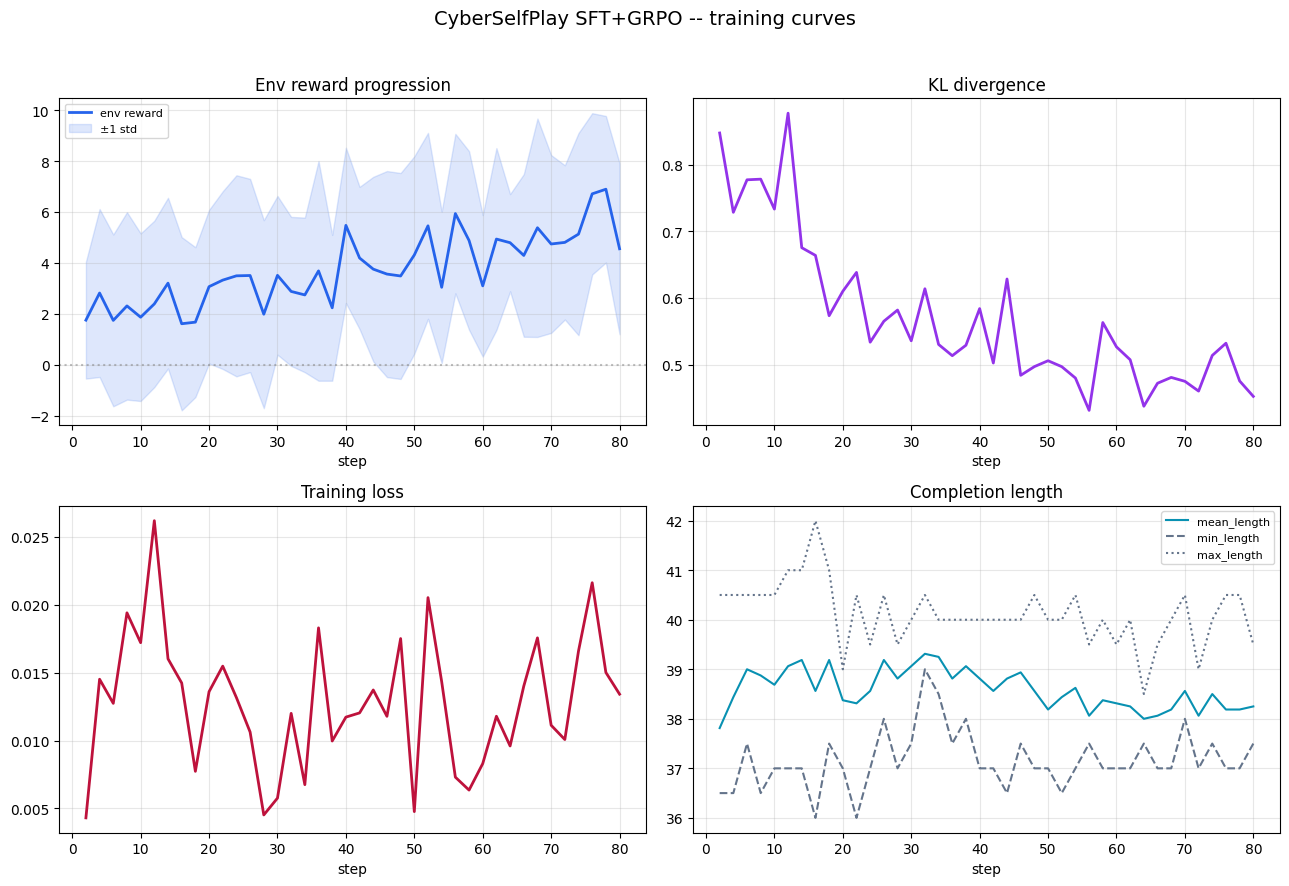

Saved -> /content/outputs_cyber/training_curves.png and /content/outputs_cyber/log_history.json


Unsloth: Restored added_tokens_decoder metadata in /content/outputs_cyber/cyber-blue-grpo-lora/tokenizer_config.json.



Saved LoRA adapter to /content/outputs_cyber/cyber-blue-grpo-lora
[push] skipped -- set HF_TOKEN as a Kaggle Secret to enable.

===== Post-GRPO sanity check =====

--- sample 1 (parse_ok=True) ---
{"actor": "blue", "tool_name": "rotate_secrets", "target": "host-02", "params": {}, "rationale": "rotate sensitive files"}
Parsed: {'actor': 'blue', 'tool_name': 'rotate_secrets', 'target': 'host-02', 'params': {}, 'rationale': 'rotate sensitive files'}

--- sample 2 (parse_ok=True) ---
{"actor": "blue", "tool_name": "rotate_secrets", "target": "host-02", "params": {}, "rationale": "rotate sensitive files"}
Parsed: {'actor': 'blue', 'tool_name': 'rotate_secrets', 'target': 'host-02', 'params': {}, 'rationale': 'rotate sensitive files'}

--- sample 3 (parse_ok=True) ---
{"actor": "blue", "tool_name": "rotate_secrets", "target": "host-02", "params": {}, "rationale": "rotate sensitive files"}
Parsed: {'actor': 'blue', 'tool_name': 'rotate_secrets', 'target': 'host-02', 'params': {}, 'rationale'

In [ ]:
# =============================================================================
# CyberSelfPlay — Standalone Kaggle SFT + GRPO training (single cell)
#
# Two-phase pipeline (the standard SFT->RL recipe):
#   Phase 1 (SFT):  imitate the heuristic Blue policy on real env rollouts.
#                   Model learns the JSON action schema -- no reward shaping.
#   Phase 2 (GRPO): refine using ONLY the environment's reward signal.
#                   No string-matching tricks, no length bonuses.
#
# Stack: Unsloth 4-bit QLoRA + TRL SFTTrainer + GRPOTrainer + live env.
# Hardware: GPU T4 x2 or P100 (free 30 GPU-h/week on Kaggle).
# Wall-clock: ~10 min SFT + ~25 min GRPO = ~35 min total.
# =============================================================================

# ---------- 1) Install Unsloth + TRL + OpenEnv deps ----------
get_ipython().system('pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"')
get_ipython().system('pip install -q --upgrade git+https://github.com/huggingface/trl.git')
get_ipython().system('pip install -q sympy scipy fastapi uvicorn datasets pydantic openenv-core huggingface_hub matplotlib')

# ---------- 2) Clone your deployed Hugging Face Space ----------
import os, sys, shutil
os.chdir("/content")
shutil.rmtree("/content/cyberselfplay-env", ignore_errors=True)
get_ipython().system('git clone https://huggingface.co/spaces/HarshitShri026/cyberselfplay-env')
os.chdir("/content/cyberselfplay-env")
sys.path.insert(0, "/content/cyberselfplay-env")
get_ipython().system('pip install -q -e .')

# ---------- 3) Wipe any prior checkpoint ----------
shutil.rmtree("/content/cyberselfplay-env/outputs_cyber", ignore_errors=True)

# ---------- 4) Silence noisy warnings ----------
import warnings, logging
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("trl").setLevel(logging.WARNING)

# ---------- 5) Imports (Unsloth FIRST) ----------
import unsloth
import torch, json, random, re
from pathlib import Path
from datasets import Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig, GRPOConfig, GRPOTrainer

from cyber_selfplay_env.environment import CyberSelfPlayEnvironment
from cyber_selfplay_env.models import CyberAction
from cyber_selfplay_env.tools_blue import BLUE_TOOLS

# ---------- 6) Env vars ----------
os.environ["TRANSFORMERS_VERBOSITY"]    = "error"
os.environ["TOKENIZERS_PARALLELISM"]    = "false"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["WANDB_DISABLED"]            = "true"
os.environ["BITSANDBYTES_NOWELCOME"]    = "1"
if torch.cuda.device_count() > 1:
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
    print("Kaggle T4 x2 detected -- using GPU 0 only (Unsloth single-GPU).")

# ---------- 7) Precision ----------
has_cuda = torch.cuda.is_available()
use_bf16 = has_cuda and torch.cuda.is_bf16_supported()
use_fp16 = has_cuda and not use_bf16
print(f"CUDA: {has_cuda} | bf16: {use_bf16} | fp16: {use_fp16}")
print(f"GPU: {torch.cuda.get_device_name(0) if has_cuda else 'none'}")

# ---------- 8) Model load ----------
MAX_SEQ_LEN = 1024
LORA_RANK   = 16
BASE_MODEL  = "unsloth/Qwen2.5-Coder-1.5B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LEN,
    dtype=None,
    load_in_4bit=True,
)
tokenizer.model_max_length = MAX_SEQ_LEN
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=LORA_RANK,
    use_gradient_checkpointing="unsloth",
)

# Clear `generation_config.max_length` so it does NOT collide with `max_new_tokens`
# at every `model.generate(...)` call (silences the spammy transformers warning).
if getattr(model, "generation_config", None) is not None:
    model.generation_config.max_length = None
    model.generation_config.max_new_tokens = None

IS_LLAMA = "llama" in BASE_MODEL.lower()
IS_QWEN  = "qwen"  in BASE_MODEL.lower()

# ---------- 9) Prompt builder (single source of truth) + JSON parser ----------
# Both SFT data and GRPO inference go through tokenizer.apply_chat_template
# so the formats are byte-identical. NO hand-written prompt strings anywhere.
VALID_BLUE = list(BLUE_TOOLS)

SYSTEM_MSG = (
    "You are the Blue defender in a cyber self-play game.\n"
    "You MUST output ONLY a valid JSON object.\n"
    "No explanation. No extra text. No prefixes/suffixes.\n"
    "Output exactly ONE JSON object and stop.\n\n"
    f"Schema: {{\"actor\":\"blue\",\"tool_name\":<one of {sorted(VALID_BLUE)}>,"
    "\"target\":\"host-XX\",\"params\":{},\"rationale\":\"short\"}}"
)

def _user_msg(obs_dict: dict) -> str:
    return (
        f"Observation:\n{json.dumps(obs_dict, ensure_ascii=True)}\n\n"
        "Reply with ONE JSON line ending with '}'. Nothing else."
    )

def obs_to_prompt(obs_dict: dict) -> str:
    """Inference prompt. Same chat template SFT used, with assistant header appended."""
    return tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_MSG},
            {"role": "user",   "content": _user_msg(obs_dict)},
        ],
        tokenize=False,
        add_generation_prompt=True,
    )

# JSON_RE = re.compile(r"\{[^{}]*\}", re.DOTALL)

JSON_RE = re.compile(r"\{.*\}", re.DOTALL)

def parse_action(text: str):
    matches = JSON_RE.findall(text)
    if not matches:
        return None, False

    for m in matches:
        try:
            a = json.loads(m)
            if a.get("tool_name") in VALID_BLUE:
                a["actor"] = "blue"
                a.setdefault("target", "host-00")
                a.setdefault("params", {})
                a.setdefault("rationale", "grpo")
                return a, True
        except:
            continue

    return None, False

# =============================================================================
# PHASE 1 -- SFT warm-start (imitate heuristic Blue policy)
# =============================================================================

# ---------- 10) Heuristic Blue policy (lifted from train/colab_trl_selfplay.py) ----------
# Real catalog of `required_tool` values used by the env's instruction system
# (see cyber_selfplay_env/simulator.py::_build_instructions). Picking from this
# list means execute_instruction has a real chance (1/8) of matching.
INSTRUCTION_TOOLS = [
    "triage_alerts", "isolate_host", "deploy_patch", "rotate_secrets",
    "run_forensics", "restore_backup", "harden_policy", "publish_ioc_blocklist",
]

RATIONALE = {
    "query_siem":            "scan telemetry",
    "triage_alerts":         "investigate alert",
    "isolate_host":          "contain breach",
    "disable_account":       "lock compromised user",
    "rotate_secrets":        "remove persistence",
    "deploy_patch":          "harden vulnerable host",
    "harden_policy":         "tighten controls",
    "restore_backup":        "recover service",
    "run_forensics":         "investigate host",
    "publish_ioc_blocklist": "block known IOCs",
    "execute_instruction":   "follow playbook",
    "checkpoint_plan":       "track progress",
    "reconcile_state":       "stabilize state",
}

EPSILON_RANDOM = 0.20  # fraction of SFT examples that pick a uniformly random
                       # valid Blue action -- teaches the schema for ALL 13 tools

def heuristic_blue_action(public_state: dict, telemetry: list, t_step: int) -> dict:
    """State-conditional, diverse Blue policy.

    The previous version only ever fired ~3 branches and ~80% of the data
    became `execute_instruction`, which caused SFT mode collapse. This version
    builds a *weighted candidate set* from the current observation and samples
    one, plus a 20% epsilon-random arm. Result: the SFT corpus exercises all
    13 Blue tools with realistic targets, so the model learns the schema
    BROADLY and GRPO has real diversity to do credit assignment on.
    """
    detections = telemetry or public_state.get("detections", []) or []
    known      = int(public_state.get("known_incident_count", 0) or 0)
    instr      = public_state.get("instruction_progress", {}) or {}
    instr_pending = isinstance(instr, dict) and instr.get("completed", 0) < instr.get("total", 1)

    rand_host = lambda: f"host-{random.randint(0, 5):02d}"

    # 20% pure exploration: random valid tool with a syntactically correct payload.
    if random.random() < EPSILON_RANDOM:
        tool = random.choice(VALID_BLUE)
        if tool == "execute_instruction":
            target, params = "", {"required_tool": random.choice(INSTRUCTION_TOOLS)}
        elif tool == "disable_account":
            target, params = f"user-{random.randint(0, 3):02d}", {}
        else:
            target, params = rand_host(), {}
        return {"actor": "blue", "tool_name": tool, "target": target,
                "params": params, "rationale": RATIONALE.get(tool, "explore")}

    # Build (tool, target, params, weight) candidates from the observation.
    cands: list[tuple[str, str, dict, int]] = []

    # Always-valid baseline (covers tools that always parse but pay little).
    cands += [
        ("query_siem",       rand_host(), {}, 1),
        ("checkpoint_plan",  rand_host(), {}, 1),
        ("reconcile_state",  rand_host(), {}, 1),
        ("deploy_patch",     rand_host(), {}, 1),
        ("harden_policy",    rand_host(), {}, 1),
        ("publish_ioc_blocklist", rand_host(), {}, 1),
        ("disable_account",  f"user-{random.randint(0, 3):02d}", {}, 1),
    ]

    if detections:
        cands += [("triage_alerts", rand_host(), {}, 3)]   # +2.0 reward when valid

    if known > 0:
        cands += [
            ("isolate_host",   rand_host(), {}, 3),         # +3.0
            ("rotate_secrets", rand_host(), {}, 2),         # +4.0
            ("run_forensics",  rand_host(), {}, 2),
            ("restore_backup", rand_host(), {}, 1),
        ]

    if instr_pending:
        cands += [(
            "execute_instruction", "",
            {"required_tool": random.choice(INSTRUCTION_TOOLS)},
            2,                                              # +1.2 if right, -1.0 if wrong
        )]

    if t_step > 0 and t_step % 10 == 0:
        cands += [("checkpoint_plan", rand_host(), {}, 4)]  # +2.0 on multiples of 10

    # Weighted random sample
    pool = [(tool, tgt, params) for tool, tgt, params, w in cands for _ in range(w)]
    tool, target, params = random.choice(pool)
    return {"actor": "blue", "tool_name": tool, "target": target,
            "params": params, "rationale": RATIONALE.get(tool, "respond")}

# ---------- 11) Collect SFT dataset from real env rollouts ----------
# Uses TRL "messages" format -> chat template applied automatically AND
# prompt tokens are masked from the loss (only JSON tokens contribute).
print("\n===== Phase 1: collecting SFT data from heuristic policy =====")
N_SFT_EPISODES = 50      # ~50 episodes x ~20 steps = ~1000 (obs, action) pairs
RED_TOOLS = ["recon_network", "attempt_exploit", "lateral_move", "exfiltrate_data"]
random.seed(42)

sft_pairs = []
for ep in range(N_SFT_EPISODES):
    env = CyberSelfPlayEnvironment()
    obs = env.reset()
    for t in range(40):
        if obs.done: break
        red_act = CyberAction(actor="red",
                              tool_name=RED_TOOLS[t % len(RED_TOOLS)],
                              target=f"host-{t % 6:02d}", params={})
        red_obs = env.step(red_act)
        if red_obs.done: break
        blue_action_dict = heuristic_blue_action(
            red_obs.public_state, red_obs.telemetry, t,
        )
        obs_payload = {
            "public_state":     red_obs.public_state,
            "telemetry":        red_obs.telemetry,
            "incident_summary": red_obs.incident_summary,
        }
        sft_pairs.append({
            "messages": [
                {"role": "system",    "content": SYSTEM_MSG},
                {"role": "user",      "content": _user_msg(obs_payload)},
                {"role": "assistant", "content": json.dumps(blue_action_dict, ensure_ascii=True)},
            ]
        })
        obs = env.step(CyberAction(**blue_action_dict))
print(f"Collected {len(sft_pairs)} SFT examples in messages format.")

# Print the action distribution -- if any single tool > 50%, SFT will collapse.
from collections import Counter
_dist = Counter(json.loads(p["messages"][-1]["content"])["tool_name"] for p in sft_pairs)
print("\n[SFT] Blue tool distribution in training data:")
for tool, n in _dist.most_common():
    pct = 100 * n / len(sft_pairs)
    bar = "#" * int(pct / 2)
    print(f"  {tool:<22s} {n:>4d}  {pct:5.1f}%  {bar}")
top_pct = max(_dist.values()) / len(sft_pairs)
if top_pct > 0.5:
    print(f"\nWARNING: top tool is {top_pct:.0%} of data -- expect mode collapse.")
else:
    print(f"\n[SFT] Diversity OK -- top tool is only {top_pct:.0%} of corpus.\n")

sft_dataset = Dataset.from_list(sft_pairs)

# Pre-apply the chat template -> Unsloth's SFTTrainer wants plain text input.
def _msgs_to_text(example):
    return {"text": tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )}

sft_dataset = sft_dataset.map(_msgs_to_text, remove_columns=["messages"])
print("Sample SFT text:\n", sft_dataset[0]["text"][:400], "...\n")

# ---------- 12) SFT phase ----------
print("\n===== Phase 1: SFT (imitation learning, BFD-packed) =====")
sft_args = SFTConfig(
    output_dir                  = "/content/outputs_cyber/sft",
    learning_rate               = 2e-4,
    per_device_train_batch_size = 4,
    gradient_accumulation_steps = 4,
    num_train_epochs            = 2,
    logging_steps               = 1,
    warmup_steps                = 5,
    optim                       = "adamw_8bit",
    bf16                        = use_bf16,
    fp16                        = use_fp16,
    save_strategy               = "no",
    report_to                   = "none",
    max_length                  = MAX_SEQ_LEN,
    dataset_text_field          = "text",
    packing                     = True,
    packing_strategy            = "bfd",
)
sft_trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    args          = sft_args,
    train_dataset = sft_dataset,
)
sft_trainer.train()
print("SFT done.")

# ---------- 13) Sanity check after SFT (parses should be ~100%) ----------
# Use GREEDY decoding -- this is the truest signal of what SFT actually learned.
# Vary the env trajectory length per sample so you see different observations
# (and therefore different outputs), not 8 copies of the same one.
print("\n===== Post-SFT sanity check (greedy decoding, varied env states) =====")
FastLanguageModel.for_inference(model)
ok_count, n_check = 0, 8
example_prompt, example_gen = None, None
RED_T = ["recon_network", "attempt_exploit", "lateral_move", "exfiltrate_data"]
for i in range(n_check):
    env_t = CyberSelfPlayEnvironment(); env_t.reset()
    for t in range(random.randint(1, 6)):
        env_t.step(CyberAction(actor="red",
                               tool_name=RED_T[t % len(RED_T)],
                               target=f"host-{random.randint(0,5):02d}"))
    o = env_t.step(CyberAction(actor="red", tool_name="recon_network",
                               target=f"host-{random.randint(0,5):02d}"))
    p = obs_to_prompt({"public_state": o.public_state, "telemetry": o.telemetry,
                       "incident_summary": o.incident_summary})
    inp = tokenizer(p, return_tensors="pt").to(model.device)
    out = model.generate(
        **inp,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
    _, ok = parse_action(gen)
    ok_count += int(ok)
    print(f"sample {i+1} (parses={ok}): {gen.strip()[:200]}")
    if example_prompt is None:
        example_prompt, example_gen = p, gen

parse_rate = ok_count / n_check
print(f"\nSFT parse rate: {ok_count}/{n_check} = {parse_rate:.0%}")

if parse_rate < 0.5:
    # Print one full prompt + generation so the user can SEE what the model is doing.
    print("\n--- DEBUG: full inference prompt the model is being given ---")
    print(example_prompt)
    print("--- DEBUG: full model output ---")
    print(example_gen)
    print("--- DEBUG: example SFT training text ---")
    print(sft_dataset[0]["text"][:1500])
    print("--- end debug ---\n")
    raise RuntimeError(
        f"SFT parse rate too low ({parse_rate:.0%}). "
        "GRPO will not learn -- aborting.\n"
        "Fixes: (a) increase N_SFT_EPISODES (50 -> 100), "
        "(b) increase num_train_epochs (4 -> 6), "
        "(c) try a stronger BASE_MODEL (Qwen2.5-Coder-1.5B-Instruct-bnb-4bit)."
    )
FastLanguageModel.for_training(model)

# =============================================================================
# PHASE 2 -- GRPO refinement (env reward only, NO hand-crafted shaping)
# =============================================================================
print("\n===== Phase 2: GRPO with environment reward only =====")

# ---------- 14) Build GRPO prompts from real env states ----------
N_PROMPTS = 64
prompts = []
for _ in range(N_PROMPTS):
    env = CyberSelfPlayEnvironment(); env.reset()
    for _ in range(random.randint(0, 4)):
        env.step(CyberAction(actor="red", tool_name="attempt_exploit",
                             target=f"host-{random.randint(0,5):02d}"))
    o = env.step(CyberAction(actor="red", tool_name="recon_network", target="host-00"))
    prompts.append({"prompt": obs_to_prompt({
        "public_state": o.public_state, "telemetry": o.telemetry,
        "incident_summary": o.incident_summary,
    })})
train_dataset = Dataset.from_list(prompts)
print(f"Built {len(train_dataset)} GRPO prompts.")

# ---------- 15) Reward = environment reward only ----------
INVALID_PENALTY = -1.0    # single fixed penalty for unparseable output
_REWARD_CALLS = {"n": 0}  # track how many times compute_rewards has been called

def compute_rewards(prompts, completions, **kwargs):
    """Pure environmental reward.

    No string matching, no keyword bonuses, no length tricks.
    - parseable action  -> reward = env.step(action).reward
    - unparseable       -> reward = INVALID_PENALTY
    """
    rewards = []
    debug_text = None
    for _p, comp in zip(prompts, completions):
        text = comp if isinstance(comp, str) else comp.get("content", "")
        if debug_text is None:
            debug_text = text
        action, ok = parse_action(text)
        if not ok:
            rewards.append(INVALID_PENALTY)
            continue
        env = CyberSelfPlayEnvironment()
        env.reset()
        env.step(CyberAction(actor="red", tool_name="attempt_exploit", target="host-01"))
        try:
            obs = env.step(CyberAction(**action))
            rewards.append(float(obs.reward or 0.0))
        except Exception:
            rewards.append(INVALID_PENALTY)

    _REWARD_CALLS["n"] += 1
    if _REWARD_CALLS["n"] % 20 == 1 and debug_text:  # ~once per logging step
        n_ok = sum(1 for r in rewards if r != INVALID_PENALTY)
        print(f"[reward debug] batch_size={len(rewards)} parsed={n_ok}/{len(rewards)} "
              f"sample={debug_text.strip()[:200]!r}", flush=True)
    return rewards

# ---------- 16) Live plot + per-step print ----------
from transformers import TrainerCallback
from IPython.display import clear_output
import matplotlib.pyplot as plt

LOG_FILE = Path("/content/outputs_cyber/train_metrics.log")

class LivePlotCallback(TrainerCallback):
    def __init__(self):
        self.h = []
        LOG_FILE.parent.mkdir(parents=True, exist_ok=True)
        LOG_FILE.write_text("step\tloss\treward\treward_std\tkl\tmean_len\n")
    def on_log(self, args, state, control, logs=None, **kw):
        if not logs or "reward" not in logs: return
        row = {**logs, "step": state.global_step}
        self.h.append(row)
        loss = row.get("loss", row.get("train_loss", 0.0))
        line = (f"[step {state.global_step:>4d}] loss={loss:+.4f}  "
                f"reward={row.get('reward', 0):+.3f}  "
                f"reward_std={row.get('reward_std', 0):.3f}  "
                f"kl={row.get('kl', 0):.4f}  "
                f"mean_len={row.get('completions/mean_length', 0):.1f}")
        print(line, flush=True)
        with LOG_FILE.open("a") as f:
            f.write(f"{state.global_step}\t{loss:.6f}\t"
                    f"{row.get('reward', 0):.6f}\t{row.get('reward_std', 0):.6f}\t"
                    f"{row.get('kl', 0):.6f}\t"
                    f"{row.get('completions/mean_length', 0):.3f}\n")
        clear_output(wait=True)
        steps = [r["step"] for r in self.h]
        fig, ax = plt.subplots(2, 2, figsize=(13, 8))
        ax[0,0].plot(steps, [r.get("reward", 0) for r in self.h], "b-", linewidth=2)
        ax[0,0].axhline(0, color="gray", ls=":", alpha=0.5)
        ax[0,0].set_title("env reward (mean)"); ax[0,0].set_xlabel("step"); ax[0,0].grid(alpha=0.3)
        ax[0,1].plot(steps, [r.get("reward_std", 0) for r in self.h], color="orange", linewidth=2)
        ax[0,1].set_title("reward_std"); ax[0,1].set_xlabel("step"); ax[0,1].grid(alpha=0.3)
        ax[1,0].plot(steps, [r.get("loss", r.get("train_loss", 0.0)) for r in self.h],
                     color="#be123c", linewidth=2)
        ax[1,0].set_title("training loss"); ax[1,0].set_xlabel("step"); ax[1,0].grid(alpha=0.3)
        ax[1,1].plot(steps, [r.get("completions/mean_length", 0) for r in self.h],
                     color="cyan", linewidth=2)
        ax[1,1].set_title("mean completion length"); ax[1,1].set_xlabel("step"); ax[1,1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()

# ---------- 17) GRPO config ----------
# num_generations=8 (was 4): more samples per group -> better advantage estimates
# and less prone to mode collapse onto a single 40-token completion.
# Batch size dropped to 2 to keep VRAM the same: 2 * 8 = 16 gens per micro-batch.
training_args = GRPOConfig(
    output_dir                  = "/content/outputs_cyber",
    learning_rate               = 5e-6,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    num_generations             = 8,
    max_completion_length       = 128,
    max_steps                   = 80,
    logging_steps               = 2,
    warmup_steps                = 6,
    optim                       = "adamw_8bit",
    bf16                        = use_bf16,
    fp16                        = use_fp16,
    use_cpu                     = not has_cuda,
    save_steps                  = 20,
    report_to                   = "none",
    temperature                 = 0.9,
    top_p                       = 0.95,
    beta                        = 0.02,
    max_grad_norm               = 1.0,
)

# ---------- 18) Train ----------
trainer = GRPOTrainer(
    model         = model,
    reward_funcs  = [compute_rewards],
    args          = training_args,
    train_dataset = train_dataset,
    callbacks     = [LivePlotCallback()],
)
trainer.train()

# ---------- 19) Final summary plot + raw metrics dump ----------
OUT = Path(training_args.output_dir)
OUT.mkdir(parents=True, exist_ok=True)
history = list(trainer.state.log_history or [])
(OUT / "log_history.json").write_text(json.dumps(history, indent=2))

def _series(key):
    xs, ys = [], []
    for r in history:
        if key in r and "step" in r:
            xs.append(r["step"]); ys.append(r[key])
    return xs, ys

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("CyberSelfPlay SFT+GRPO -- training curves", fontsize=14)

ax = axes[0, 0]
rx, ry = _series("reward"); sx, sy = _series("reward_std")
if rx: ax.plot(rx, ry, color="#2563eb", linewidth=2, label="env reward")
if sx and len(ry) == len(sy):
    ax.fill_between(sx, [m-s for m,s in zip(ry,sy)], [m+s for m,s in zip(ry,sy)],
                    color="#2563eb", alpha=0.15, label="±1 std")
ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Env reward progression"); ax.set_xlabel("step")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
kx, ky = _series("kl")
if kx: ax.plot(kx, ky, color="#9333ea", linewidth=2)
ax.set_title("KL divergence"); ax.set_xlabel("step"); ax.grid(alpha=0.3)

ax = axes[1, 0]
lx, ly = _series("loss")
if not lx: lx, ly = _series("train_loss")
if lx: ax.plot(lx, ly, color="#be123c", linewidth=2)
ax.set_title("Training loss"); ax.set_xlabel("step"); ax.grid(alpha=0.3)

ax = axes[1, 1]
for k, color, ls in [("completions/mean_length", "#0891b2", "-"),
                     ("completions/min_length",  "#64748b", "--"),
                     ("completions/max_length",  "#64748b", ":")]:
    xs, ys = _series(k)
    if xs: ax.plot(xs, ys, color=color, linestyle=ls, label=k.split("/")[-1])
ax.set_title("Completion length"); ax.set_xlabel("step")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUT / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {OUT/'training_curves.png'} and {OUT/'log_history.json'}")

# ---------- 20) Save adapter ----------
SAVE_DIR = "/content/outputs_cyber/cyber-blue-grpo-lora"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nSaved LoRA adapter to {SAVE_DIR}")

# ---------- 21) (Optional) Push to HF Hub ----------
PUSH_TO_HUB    = True
HF_TARGET_REPO = "HarshitShri026/cyber-blue-grpo"

try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    HF_TOKEN = ""

if PUSH_TO_HUB and HF_TOKEN:
    from huggingface_hub import HfApi, login
    login(token=HF_TOKEN)
    api = HfApi()
    api.create_repo(repo_id=HF_TARGET_REPO, repo_type="model", exist_ok=True)
    api.upload_folder(repo_id=HF_TARGET_REPO, folder_path=SAVE_DIR, repo_type="model")
    for fname in ("training_curves.png", "log_history.json", "train_metrics.log"):
        fpath = OUT / fname
        if fpath.exists():
            api.upload_file(path_or_fileobj=str(fpath), path_in_repo=fname,
                            repo_id=HF_TARGET_REPO, repo_type="model")
    print(f"Uploaded -> https://huggingface.co/{HF_TARGET_REPO}")
else:
    print("[push] skipped -- set HF_TOKEN as a Kaggle Secret to enable.")

# ---------- 22) Final sanity check (varied env states) ----------
print("\n===== Post-GRPO sanity check =====")
FastLanguageModel.for_inference(model)
for i in range(3):
    env_t = CyberSelfPlayEnvironment(); env_t.reset()
    for t in range(random.randint(1, 6)):
        env_t.step(CyberAction(actor="red",
                               tool_name=RED_T[t % len(RED_T)],
                               target=f"host-{random.randint(0,5):02d}"))
    o = env_t.step(CyberAction(actor="red", tool_name="recon_network",
                               target=f"host-{random.randint(0,5):02d}"))
    p = obs_to_prompt({"public_state": o.public_state, "telemetry": o.telemetry,
                       "incident_summary": o.incident_summary})
    inp = tokenizer(p, return_tensors="pt").to(model.device)
    out = model.generate(
        **inp,
        max_new_tokens=128,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    gen = tokenizer.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
    action, ok = parse_action(gen)
    print(f"\n--- sample {i+1} (parse_ok={ok}) ---")
    print(gen.strip()); print("Parsed:", action)
print("\nDone.")
